# 🔬 Predicting Thermoelectric Properties (K)

1. Import Libraries  
2. Data Upload & Loading  
3. Data Cleaning  
4. Exploratory Data Analysis (EDA)  
5. Train-Test Split & Scaling  
6. Linear Regression Model  
7. Decision Tree Regression Model  
8. Visualization: Predictions vs Actual  
9. Model Comparison Table  
10. Cross-Validation & Additional Models  
11. Model Performance Comparison Chart  

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from google.colab import files

# Upload and Load Data

In [2]:
uploaded = files.upload()

file_path = 'data.xlsx'

data = pd.read_excel(file_path, sheet_name='data')

Saving data.xlsx to data.xlsx


# Data Cleaning

In [3]:
data.replace('-', np.nan, inplace=True)
data = data.apply(pd.to_numeric, errors='coerce')

features = data[['Fe', 'C', 'Mn', 'Ni', 'Mo', 'V', 'Cr', 'Cu', 'Al', 'Ti',
                 'Co', "TC"]]
target = data['K']

cols_to_check = features.columns.tolist() + [target.name]
data_cleaned = data.dropna(subset=cols_to_check)

features = data_cleaned[features.columns]
target = data_cleaned[target.name]

# Exploratory Data Analysis (EDA)

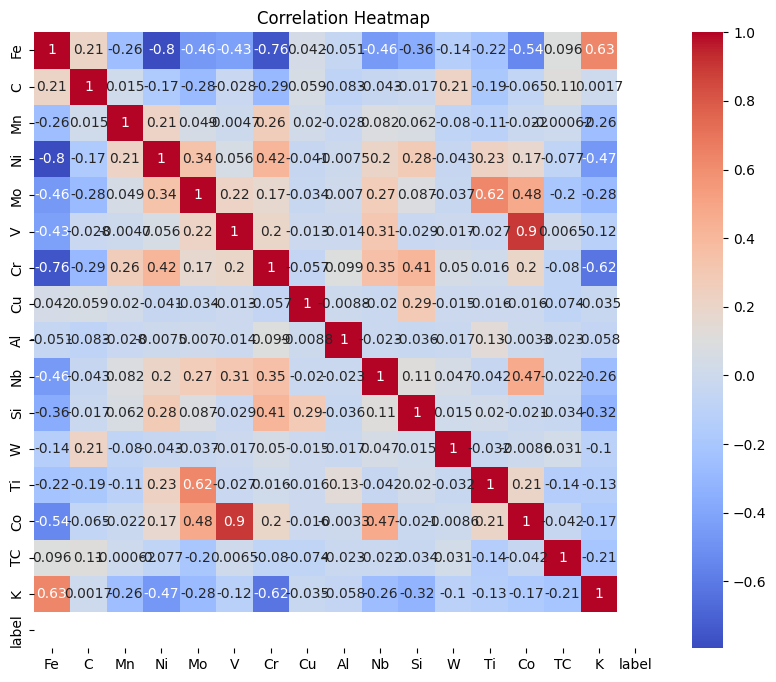

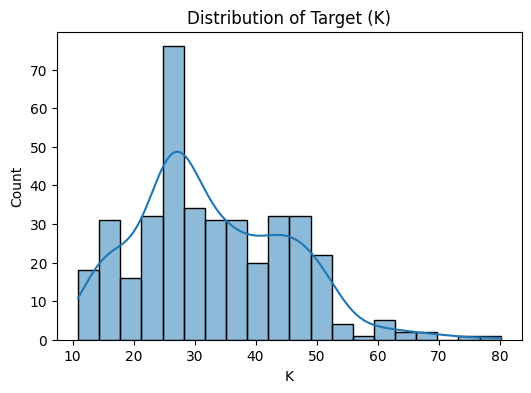

In [4]:
# --- Exploratory Data Analysis (EDA) ---

import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data_cleaned.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Distribution of target variable
plt.figure(figsize=(6,4))
sns.histplot(target, kde=True, bins=20)
plt.title("Distribution of Target (K)")
plt.show()

# Train-Test Split and Scaling

In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target,
                                                    test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression Model

In [6]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = lr_model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Linear Regression - MAE: {mae}, RMSE: {rmse}, R2: {r2}')

Linear Regression - MAE: 6.403568163316563, RMSE: 8.855097552040204, R2: 0.546682772300732


# Decision Tree Model

In [7]:
# Train Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test_scaled)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f'Decision Tree Regression - MAE: {mae_dt}, RMSE: {rmse_dt}, R2: {r2_dt}')

Decision Tree Regression - MAE: 1.7265822784810132, RMSE: 2.9593447786608684, R2: 0.9493701482798503


# Model Performance Visualization

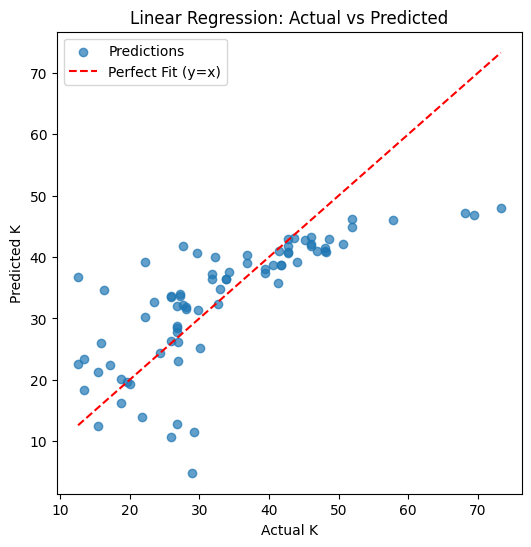

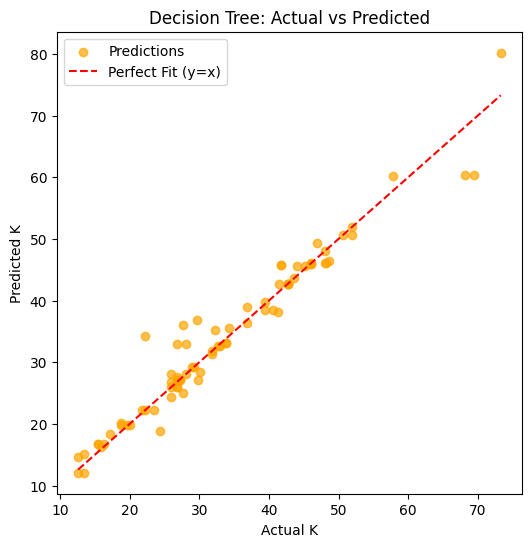

In [8]:
# --- Linear Regression Predictions vs Actual ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7, label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit (y=x)")
plt.xlabel("Actual K")
plt.ylabel("Predicted K")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()

# --- Decision Tree Predictions vs Actual ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dt, alpha=0.7, color='orange', label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit (y=x)")
plt.xlabel("Actual K")
plt.ylabel("Predicted K")
plt.title("Decision Tree: Actual vs Predicted")
plt.legend()
plt.show()


# Comparing Models

In [9]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [mae, mae_dt],
    "RMSE": [rmse, rmse_dt],
    "R2 Score": [r2, r2_dt]
})

print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  6.403568  8.855098  0.546683
1      Decision Tree  1.726582  2.959345  0.949370


# Cross-Validation

In [10]:
from sklearn.model_selection import cross_val_score

cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='r2')
cv_scores_dt = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring='r2')

print("Linear Regression CV R2:", cv_scores_lr.mean())
print("Decision Tree CV R2:", cv_scores_dt.mean())

Linear Regression CV R2: 0.5635680814028378
Decision Tree CV R2: 0.9134935630975184


# Model Comparison Chart

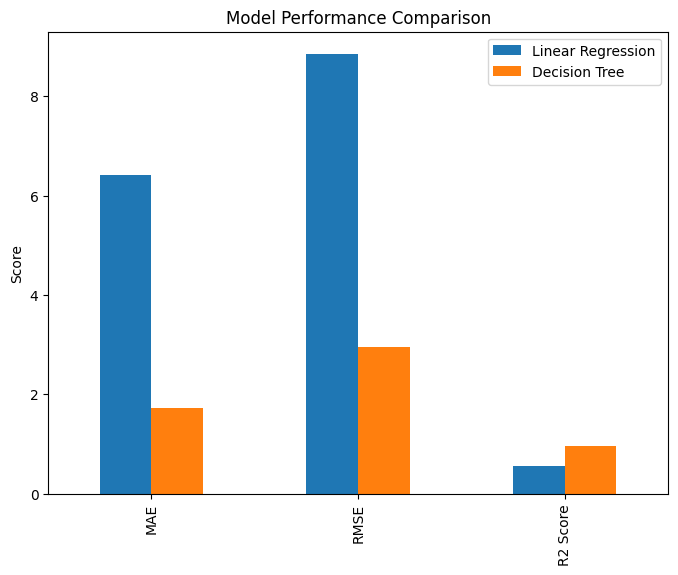

In [11]:
metrics = {
    "Linear Regression": [mae, rmse, r2],
    "Decision Tree": [mae_dt, rmse_dt, r2_dt]
}

df_metrics = pd.DataFrame(metrics, index=["MAE", "RMSE", "R2 Score"])
df_metrics.plot(kind="bar", figsize=(8,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()